# bert-1
- run pipeline

In [ ]:
from nlp import ClimateBERTAnalyzer, analyze_reports

stats = analyze_reports('../data/reports/Baosteel')
# stats = analyze_reports("../data/reports")

# bert-2
- run vizualisations

In [4]:
from nlp import ClimateBERTVisualizer, visualize_results

visualize_results("../cache", "../out")

✅ Loaded: 193 reports, 15 companies, 2013-2024

EXPORTING CSV FILES
   ✓ company_year.csv (129 rows)
   ✓ company_totals.csv (15 companies)
   ✓ yearly_industry.csv (12 years)
   ✓ funnel_company_year.csv (129 rows)

   📁 All CSVs saved to: ../out/

GENERATING PLOTS
   ✓ slide_main.png
   ✓ slide_sentiment_trend.png
   ✓ talk_score_trend.png
   ✓ funnel_trend.png
   ✓ talk_score_per_company.png
   ✓ per_company_components.png
   ✓ per_company_sentiment.png
   ✓ sentiment_all_companies.png
   ✓ n0_funnel.png
   ✓ n0_quality_comparison.png
   ✓ n0_per_company.png
   ✓ n0_gap_analysis.png

   📁 All plots saved to: ../out/

   Generating word frequency plots...

   📊 ALL CHUNKS (top 30):
   environment(17950), sustainable(17493), production(16608), emission(14006), management(13797), energy(12048), financial(11688), development(11410), business(11035), reduction(10864), products(9790), million(9437), carbon(9152), iron(8384), process(6902)

   🌱 OPPORTUNITY chunks (top 15):
   production(7

# rag

## Reload modules

run when changing code in .py file

In [ ]:
%load_ext autoreload
%autoreload 2
# %aimport nlp.rag

# if still didnt reload changes do 'restart kernel' / restart vscode

## Model Testing

Test which models work for extraction (format compliance + quality).

In [ ]:
from nlp.test import save_test_results
from nlp.test import test_models, compare_extractions
from nlp import Config

# Available models (for reference):
# Groq:   mixtral-8x7b-32768, gemma2-9b-it
# Ollama: gemma3:4b

MODELS = [
    # Groq (free tier: 6k TPM - use small batch_size)
    # Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3),
    # Config(llm_provider="groq", model="llama-3.3-70b-versatile", approach="exhaustive", ctx=128000, batch_size=5),

    # RAG approach
    Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=False),

    # Ollama
    # Tested: gemma3:4b ctx=4096 works but slow (108s), qwen2.5:3b fails format
    # Config(llm_provider="ollama", model="qwen2.5:3b", approach="exhaustive", ctx=4096),  # 1.9GB - FAIL format
    # Config(llm_provider="ollama", model="gemma3:4b", approach="exhaustive", ctx=4096),   # 3.3GB - PASS but slow

    # Testing: smaller ctx to reduce VRAM pressure on 4GB GPU
    # Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096),  # 2.0GB
    # Config(llm_provider="ollama", model="llama3.1:8b ", approach="exhaustive", ctx=4096),  # 2.0GB

    # Config(llm_provider="ollama", model="qwen3:4b", approach="exhaustive", ctx=2048),     # 2.5GB
]

results = test_models(MODELS, skip_extraction=False)
compare_extractions(results)
save_test_results(results) # Save test results (same format as full pipeline: CSV + stats.json with prompts)

MODEL TESTING (1 models) - 006/2023

--- groq/llama-3.1-8b-instant [rag, top_k=20] (ctx=128,000 → 72 chunks) ---
    ERROR: Error code: 503 - {'error': {'message': 'llama-3.1-8b-instant is currently over capacity. Please try again and back off exponentially. Visit https://groqstatus.com to see if there is an active incident.', 'type': 'internal_server_error'}}

Model                                    Approach     Fmt    Time    B     M     Chunks
----------------------------------------------------------------------
groq/llama-3.1-8b-instant                             ERROR
Need 2+ models with extraction results to compare


## Run Extraction

Configure and run the full extraction pipeline.

In [ ]:
from nlp import load_pipeline, Config

# Exhaustive (all chunks batched through LLM)
# config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3)
# config = Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096)

config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=False)

pipeline = load_pipeline(config)
pipeline.print_chunk_overview()

✓ Pipeline initialized (GPU: NVIDIA T1200 Laptop GPU (3.9GB))
✓ Loaded 15593 chunks from 15 companies (../cache)
Loading embedding model: Snowflake/snowflake-arctic-embed-s
Building FAISS index from 15593 chunks...
✓ FAISS index built (15593 vectors, 222.8s)
✓ FAISS index saved to ../cache/faiss_index

CHUNK DISTRIBUTION (Years × Companies)
Year      ArcelorMit..    Acerinox    Outokumpu    Salzgitter     SSAB    TataSteelN..    Celsa    Voestalpine    Acciaierie..    TataSteelUK    Dillinger    SIDENOR    Feralpi    NipponSteel    Baosteel    TOTAL
                 (001)       (002)        (003)         (004)    (005)           (006)    (007)          (008)           (009)          (010)        (012)      (013)      (014)          (015)       (016)
------  --------------  ----------  -----------  ------------  -------  --------------  -------  -------------  --------------  -------------  -----------  ---------  ---------  -------------  ----------  -------
2013               320     

In [ ]:
results = pipeline.extract_all_companies(resume=True)


EXTRACTION RUN
  LLM: groq/llama-3.1-8b-instant
  Context: 128,000 tokens → 72 chunks/batch
  Chunks: 15593 (1750 avg chars, 38-19629 range)
  Groups: 132 | Est. LLM calls: 568


Extracting: ArcelorMittal (001)
Years: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Retrieval: top_k=20, strategy=mmr


  001:   0%|          | 0/13 [00:00<?, ?it/s]

Loading Groq: llama-3.1-8b-instant
    B done: 0 found in 1 batches (0.4s)          


  001:   8%|▊         | 1/13 [00:00<00:10,  1.16it/s]

    M done: 3 found in 1 batches (0.3s)          
    B done: 12 found in 1 batches (0.4s)          


...

  016:  83%|████████▎ | 10/12 [00:40<00:13,  6.74s/it]

    M done: 14 found in 1 batches (5.6s)          
    B done: 81 found in 1 batches (8.5s)          


  016:  92%|█████████▏| 11/12 [00:53<00:08,  8.31s/it]

    M done: 0 found in 1 batches (4.3s)          


    M done: 13 found in 1 batches (7.9s)          
  ✓ Extracted 390 barriers, 68 motivators

✓ EXTRACTION COMPLETE
  Time: 1461.8s (24.4min)
  Results: 1698 barriers, 1255 motivators
  Saved: ../out/stats.json



In [4]:
# Display results for a specific company
company_id = list(results.keys())[0]  # First company
df_barriers, df_motivators = results[company_id]
pipeline.display_results(company_id, df_barriers, df_motivators)

ValueError: too many values to unpack (expected 2)

# topic modelling

📝 Config logged to ../out/topics/config_log.txt

📂 LOADING DATA

📂 Loading 15 CSV files from ../out...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 569.59it/s]


⚠️  Error loading barriers_010.csv: No columns to parse from file
✅ Loaded 1698 rows from 14 files

📂 Loading 15 CSV files from ../out...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 986.12it/s]

⚠️  Error loading motivators_010.csv: No columns to parse from file
⚠️  Error loading motivators_009.csv: No columns to parse from file
✅ Loaded 1255 rows from 13 files

🎯 TOPIC MODELING: BARRIERS
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
🔄 Force retrain enabled, ignoring cache

🔄 Processing 1698 documents from 'barriers'...

🧮 Generating embeddings for 1698 documents...

🤖 Loading embedding model: BAAI/bge-small-en-v1.5


...


✅ Found 9 topics
   📍 341 documents classified as outliers (topic -1)
✅ Saved model to ../out/topics/motivators_model
✅ Saved embeddings to ../out/topics/motivators_embeddings.npy

📋 Topic Summary:
------------------------------------------------------------
Topic -1:  341 docs | carbon neutrality, contribute carbon, opportunity carbon, emissions trading, ghg
Topic 0:  417 docs | ghg reduction, reduce emissions, reduce ghg, emissions opportunity, energy efficiency
Topic 1:  276 docs | sustainable products, sustainability, sustainable practices, sustainable, sustainable development
Topic 2:  103 docs | steel technology, emissions steelmaking, carbon steel, steel production, emissions steel
Topic 3:   31 docs | ghg emissions, emissions supply, ghg, emissions industrial, reduce ghg
Topic 4:   29 docs | 106 esrs, included esrs, esrs s1, e1 esrs, 105 esrs
Topic 5:   25 docs | zero targets, zero target, targets net, net zero, zero goals
Topic 6:   13 docs | emissions driver, fuels driver, d

13it [00:04,  2.93it/s]


  ✓ motivators_over_time.html


13it [00:04,  3.21it/s]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png
  ✓ Saved motivators_company_year.csv

✅ PIPELINE COMPLETE
📁 Results saved to: ../out/topics


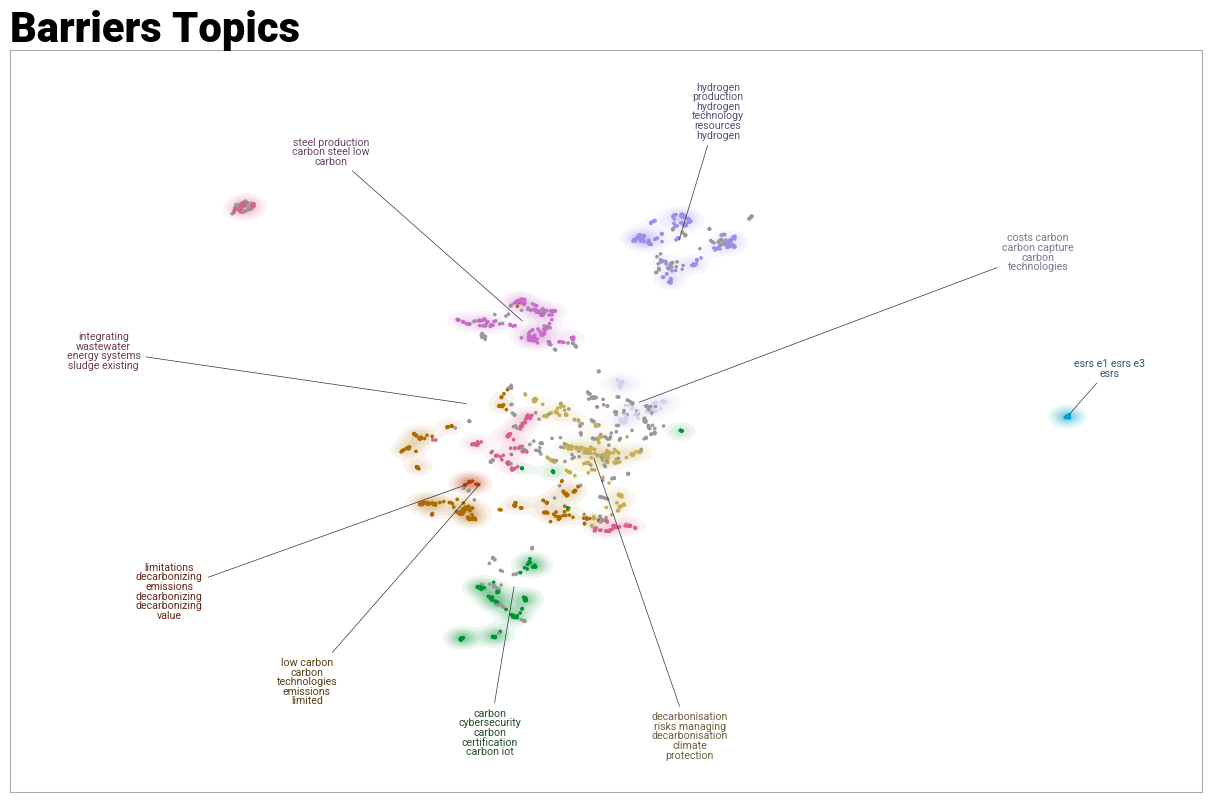

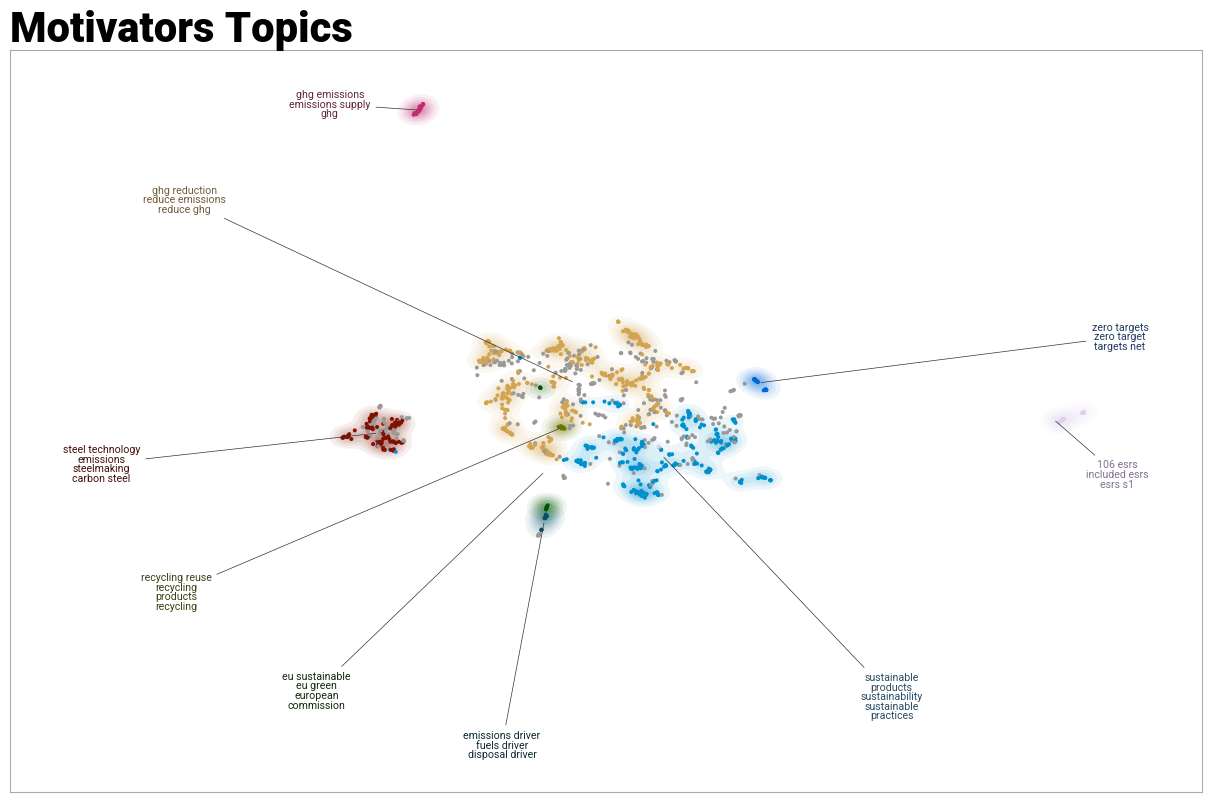

In [3]:
from nlp import TopicModelConfig, run_topic_modeling_pipeline

# Set True to ignore cached model/embeddings and retrain from scratch
FORCE_RETRAIN = True

config = TopicModelConfig(
    # Embedding model
    # embedding_model="sentence-transformers/all-mpnet-base-v2",
    embedding_model="BAAI/bge-small-en-v1.5",

    batch_size=64,

    # UMAP (dimensionality reduction)
    umap_n_neighbors=30,
    umap_n_components=15,
    umap_min_dist=0.05,
    umap_metric='cosine',
    umap_random_state=42,

    # HDBSCAN (clustering)
    hdbscan_min_cluster_size=10,  # Higher = fewer topics
    hdbscan_min_samples=2,        # Lower = less outliers
    hdbscan_metric='euclidean',
    hdbscan_cluster_selection_method='leaf',  # 'eom' (inclusive) or 'leaf' (tight, more cleanup required)

    # Vectorizer (c-TF-IDF)
    vectorizer_ngram_range=(1, 2),
    vectorizer_min_df=1,
    vectorizer_max_df=0.95,

    # Topic representation
    mmr_diversity=0.2, # 0 - pure relevance, redundant/simi word ... 1 - pure diverse. max diff word
    top_n_words=10,
    nr_topics=10,  # Set None for auto, or int to reduce post-hoc
    calculate_probabilities=True,

    # Outlier reduction (post-hoc)
    reduce_outliers=False,  # Reassign outliers to nearest topic
    reduce_outliers_strategy='embeddings',  # 'embeddings', 'c-tf-idf', or 'distributions'

    # Visualization UMAP (separate 2D projection)
    viz_umap_n_neighbors=10,
    viz_umap_n_components=2,
    viz_umap_min_dist=0.0,

    # LLM for topic labeling
    ollama_model="gemma3:4b",  # Fast + follows format. Avoid qwen3 (hidden thinking = slow)
    ollama_base_url="http://localhost:11434",
    llm_temperature=0.0,

    # Misc
    verbose=True,
    embeddings_cache_path=None,
)

results = run_topic_modeling_pipeline(
    data_folder="../out",
    output_folder="../out/topics",
    config=config,
    force_retrain=FORCE_RETRAIN
)
# Access results
barriers_df = results['barriers']['df']
motivators_df = results['motivators']['df']

In [ ]:
motivators_df

,company_id,company,year,motivators,topic
0,13,SIDENOR,2022,Our commitment to contribute in the global eff...,0
1,13,SIDENOR,2022,Our commitment to minimize our carbon emissions,0
2,13,SIDENOR,2022,Our commitment to reduce our energy consumption,0
3,13,SIDENOR,2022,"Our commitment to use energy in a responsible,...",0
4,13,SIDENOR,2022,Our commitment to minimize our carbon footprint,0
...,...,...,...,...,...
1250,15,NipponSteel,2025,Development of hydroformed steel tubes for sus...,2
1251,15,NipponSteel,2025,Development of titanium alloys for mufflers an...,2
1252,15,NipponSteel,2025,Development of TranTixxii TP method and titani...,-1
1253,15,NipponSteel,2025,Development of stainless steel cold-rolled she...,2
